# Foundation models and Parameter-Efficient Fine-Tuning (PEFT)

In this lab we look at adapters for a histopathology classification task, built on top
of a self-supervised foundation model (DINOv2).

There are two parts:

1. From-scratch adapters. We implement Bottleneck, AdaptFormer, LoRA, VeRA and
   prompt-tuning by hand, freeze the backbone, and compare them.
2. PEFT. We redo LoRA (and a couple of other methods) with Hugging Face's
   [`peft`](https://github.com/huggingface/peft) library, so you can see how the same
   ideas are used in practice with only a few lines of code.


## 0. Setup

In [ ]:
# Core deps. peft/transformers are only needed for Part 2.
!pip install torchmetrics einops --quiet
!pip install "peft==0.13.2" "transformers>=4.40" --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 6.7 MB/s eta 0:00:00


In [1]:
import os
import gzip
import shutil
import gdown
import random

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchmetrics
import matplotlib.pyplot as plt

from einops import repeat
from tqdm.notebook import tqdm
from urllib.request import urlretrieve
from torch.utils.data import Subset, DataLoader

In [2]:
def set_seed(seed=0):
    """Seed the RNGs so runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 1. Foundation model

We use [DINOv2 (Oquab et al., 2023)](https://arxiv.org/abs/2304.07193), a foundation model
trained self-supervised on a large set of natural images. It is a Vision Transformer (ViT).

![ViT architecture](https://viso.ai/wp-content/uploads/2021/09/vision-transformer-vit.png)

For speed we use the small variant (`vits`), whose feature dimension is 384.


In [3]:
def build_dino(model_type='vits'):
    """
    Load a pretrained DINOv2 model.
        model_type [str]: one of vits, vitb, vitl, vitg
    returns a DinoVisionTransformer.
    """
    return torch.hub.load('facebookresearch/dinov2', f'dinov2_{model_type}14')


# Feature dimensions for each DINOv2 variant (handy when adding the probing head).
DINO_FEATURE_DIM = {'vits': 384, 'vitb': 768, 'vitl': 1024, 'vitg': 1536}

## 2. Dataset — PatchCamelyon (PCam)

PCam is a set of 96x96 RGB histopathology patches taken from Camelyon whole-slide
images, each with a binary label (whether metastatic tissue is present). To keep training
fast we use only the validation split, which we then split again into train and val.


In [4]:
# File IDs from the basveeling/pcam repo
FILES = {
    'camelyonpatch_level_2_split_valid_x.h5.gz': '1hgshYGWK8V-eGRy8LToWJJgDU_rXWVJ3',
    'camelyonpatch_level_2_split_valid_y.h5.gz': '1bH8ZRbhSVAhScTS0p9-ZzGnX91cHT3uO',
}

os.makedirs('pcam', exist_ok=True)
for name, fid in FILES.items():
    out_gz = os.path.join('pcam', name)
    out = out_gz.replace('.gz', '')
    if os.path.exists(out):
        continue
    gdown.download(id=fid, output=out_gz, quiet=False)
    with gzip.open(out_gz, 'rb') as f_in, open(out, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(out_gz)

In [5]:
# DINOv2 uses a patch size of 14, so the image side must be a multiple of 14.
frame_size = 98  # 98 = 7 * 14
dataset_transforms = transforms.Compose([
    transforms.Resize((frame_size, frame_size)),
    transforms.ToTensor(),
])
dataset = torchvision.datasets.PCAM('.', 'val', transform=dataset_transforms)
print('Total patches:', len(dataset))

Total patches: 32768


In [6]:
split_ratio = 0.7

indices = list(range(len(dataset)))
random.shuffle(indices)
split = int(split_ratio * len(indices))

train_dataset = Subset(dataset, indices[:split])
val_dataset = Subset(dataset, indices[split:])
print(f'train: {len(train_dataset)}  |  val: {len(val_dataset)}')

train: 22937  |  val: 9831


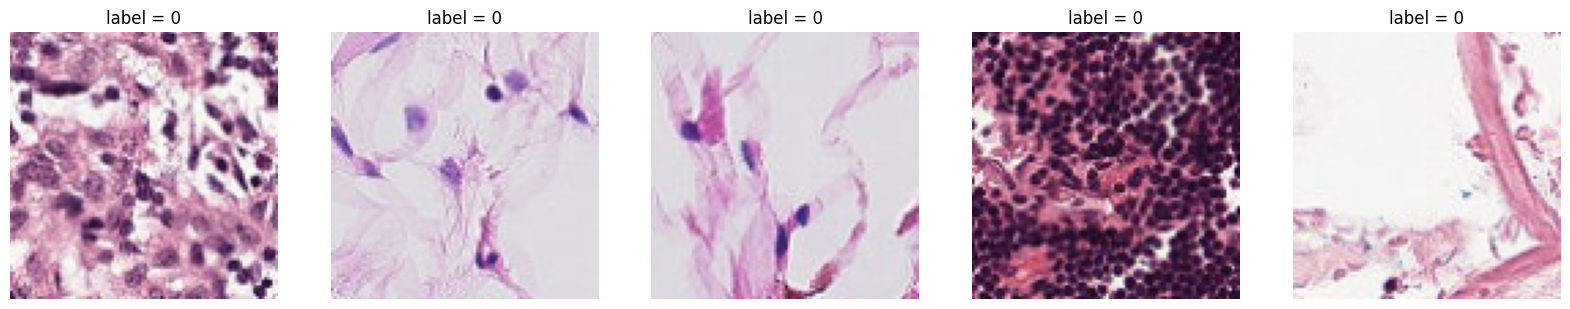

In [7]:
num_imgs = 5
fig, axs = plt.subplots(1, num_imgs, figsize=(4 * num_imgs, 4))
for i in range(num_imgs):
    img, label = train_dataset[i]
    axs[i].imshow(img.permute(1, 2, 0))
    axs[i].set_title(f'label = {label}')
    axs[i].axis('off')
plt.show()

## 3. Helper functions

We put a linear-probing head on top of the frozen backbone and train it together with
whatever adapter we insert. We also provide reusable training and parameter-counting
helpers.


In [8]:
def add_linear_probing(model, feature_dim=384, num_classes=2):
    """
    Replace the model head with a linear classifier.
    For the binary case we output a single logit/probability (BCE).
    """
    out_dim = 1 if num_classes == 2 else num_classes
    final = nn.Sigmoid() if num_classes == 2 else nn.Softmax(dim=-1)
    model.head = nn.Sequential(nn.Linear(feature_dim, out_dim), final)
    return model

In [9]:
def count_parameters(model):
    """Return (trainable, total) parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


def report_parameters(model, name=''):
    trainable, total = count_parameters(model)
    print(f'{name+": " if name else ""}{trainable:,} trainable / {total:,} total '
          f'({100 * trainable / total:.2f}%)')
    return trainable, total

In [10]:
@torch.no_grad()
def _gather(metric_fns, preds, labels):
    preds = torch.tensor(preds)
    labels = torch.tensor(labels)
    return {k: fn(preds, labels).item() for k, fn in metric_fns.items()}


def train_model(model, train_dataloader, val_dataloader, optimizer, criterion,
                device, num_epochs=10):
    """Train `model` and return a per-epoch history dict."""
    model.to(device)
    metric_fns = {'F1': torchmetrics.F1Score('binary'),
                  'AUC': torchmetrics.AUROC('binary')}
    history = {'train_loss': [], 'val_loss': [],
               'train_F1': [], 'val_F1': [], 'train_AUC': [], 'val_AUC': []}

    for epoch in range(num_epochs):
        # ---- train ----
        model.train()
        losses, labels, preds = [], [], []
        for x, y in tqdm(train_dataloader, leave=False, desc=f'train {epoch+1}/{num_epochs}'):
            optimizer.zero_grad()
            out = model(x.to(device))
            loss = criterion(out, y.to(device).float().unsqueeze(-1))
            loss.backward()
            optimizer.step()
            losses.append(loss.item() * len(y))
            labels.extend(y.cpu().unsqueeze(-1).tolist())
            preds.extend(out.detach().cpu().tolist())
        tr = _gather(metric_fns, preds, labels)
        tr_loss = sum(losses) / len(labels)

        # ---- val ----
        model.eval()
        losses, labels, preds = [], [], []
        for x, y in tqdm(val_dataloader, leave=False, desc=f'val {epoch+1}/{num_epochs}'):
            with torch.no_grad():
                out = model(x.to(device))
            loss = criterion(out, y.to(device).float().unsqueeze(-1))
            losses.append(loss.item() * len(y))
            labels.extend(y.cpu().unsqueeze(-1).tolist())
            preds.extend(out.cpu().tolist())
        va = _gather(metric_fns, preds, labels)
        va_loss = sum(losses) / len(labels)

        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_F1'].append(tr['F1']);  history['val_F1'].append(va['F1'])
        history['train_AUC'].append(tr['AUC']); history['val_AUC'].append(va['AUC'])

        print(f'[{epoch+1:2d}/{num_epochs}] '
              f'train loss {tr_loss:.4f} F1 {tr["F1"]:.4f} AUC {tr["AUC"]:.4f} | '
              f'val loss {va_loss:.4f} F1 {va["F1"]:.4f} AUC {va["AUC"]:.4f}')

    return history

## 3b. A look inside DINOv2

Before patching the network it helps to see how a DINOv2 ViT is actually built. The
adapters below target specific submodules (the attention `qkv`/`proj` projections, the
per-block `mlp`, the `norm1`/`norm2` layer norms, the prepended tokens), so knowing where
those live makes the insertion functions easier to follow.

We print three things:

1. the top-level structure (patch embedding, the stack of transformer `blocks`, final norm/head),
2. the layout of a single encoder block, which is the repeating unit we adapt,
3. a named-parameter summary, so we can see which tensors exist and how big they are.


In [11]:
# Build a fresh small backbone just for inspection.
dino = build_dino('vits')

print('=== Top-level modules ===')
for name, module in dino.named_children():
    # For the block list, show how many blocks there are rather than all of them.
    if name == 'blocks':
        print(f'{name:<16} ModuleList of {len(module)} transformer blocks')
    else:
        print(f'{name:<16} {module.__class__.__name__}')

print(f'\nDepth (number of blocks): {len(dino.blocks)}')
print(f'Embedding / feature dim : {dino.norm.normalized_shape[0]}')

Using cache found in /linkhome/rech/genysv01/ucy78gw/.cache/torch/hub/facebookresearch_dinov2_main
/linkhome/rech/genysv01/ucy78gw/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/linkhome/rech/genysv01/ucy78gw/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/linkhome/rech/genysv01/ucy78gw/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


=== Top-level modules ===
patch_embed      PatchEmbed
blocks           ModuleList of 12 transformer blocks
norm             LayerNorm
head             Identity

Depth (number of blocks): 12
Embedding / feature dim : 384


In [12]:
# Detailed layout of a SINGLE encoder block — this is the unit every adapter modifies.
print('=== One encoder block (dino.blocks[0]) ===')
print(dino.blocks[0])

=== One encoder block (dino.blocks[0]) ===
NestedTensorBlock(
  (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True, bias=True)
  (attn): MemEffAttention(
    (qkv): Linear(in_features=384, out_features=1152, bias=True)
    (attn_drop): Dropout(p=0.0, inplace=False)
    (proj): Linear(in_features=384, out_features=384, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (ls1): LayerScale()
  (drop_path1): Identity()
  (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True, bias=True)
  (mlp): Mlp(
    (fc1): Linear(in_features=384, out_features=1536, bias=True)
    (act): GELU(approximate='none')
    (fc2): Linear(in_features=1536, out_features=384, bias=True)
    (drop): Dropout(p=0.0, inplace=False)
  )
  (ls2): LayerScale()
  (drop_path2): Identity()
)


In [19]:
dino

NameError: name 'dino' is not defined

In [13]:
block

NameError: name 'block' is not defined

In [ ]:
# Named-parameter summary for one block, so we can see the exact tensor names
# the freeze functions will match against (e.g. "attn.qkv", "mlp.fc1", "norm1").
print('=== Parameters of dino.blocks[0] ===')
for name, p in dino.blocks[0].named_parameters():
    print(f'{name:<28} {tuple(p.shape)}')

# Quick sanity check of the pieces the adapters rely on.
block = dino.blocks[0]
print('\nKey submodules used by the adapters:')
print('  attn.qkv  :', block.attn.qkv)    # fused Q,K,V projection  -> LoRA / VeRA
print('  attn.proj :', block.attn.proj)   # attention output proj   -> Bottleneck
print('  mlp.fc1   :', block.mlp.fc1)     # MLP hidden              -> AdaptFormer / Bottleneck
print('  norm1     :', block.norm1)       # pre-attention layernorm
print('  norm2     :', block.norm2)       # pre-MLP layernorm       -> folded into AdaptFormer

del dino  # free the inspection model

## 4. Adapters (from scratch)

Adapters are small modules inserted into a pretrained architecture. The idea is to avoid
fine-tuning the whole model, which would train a large number of parameters and risk
forgetting what was learned during pretraining. When we train an adapter the backbone is
frozen, except for the inserted adapter (and, for some methods, the layer norms).

For each adapter we define three things: the adapter module, the insertion function, and
the freezing function.


### 4.1. Bottleneck adapter

The [bottleneck adapter](https://arxiv.org/abs/1902.00751) adds a 2-layer adapter at two
positions in each transformer encoder block. For this method the layer norms are also
left unfrozen.


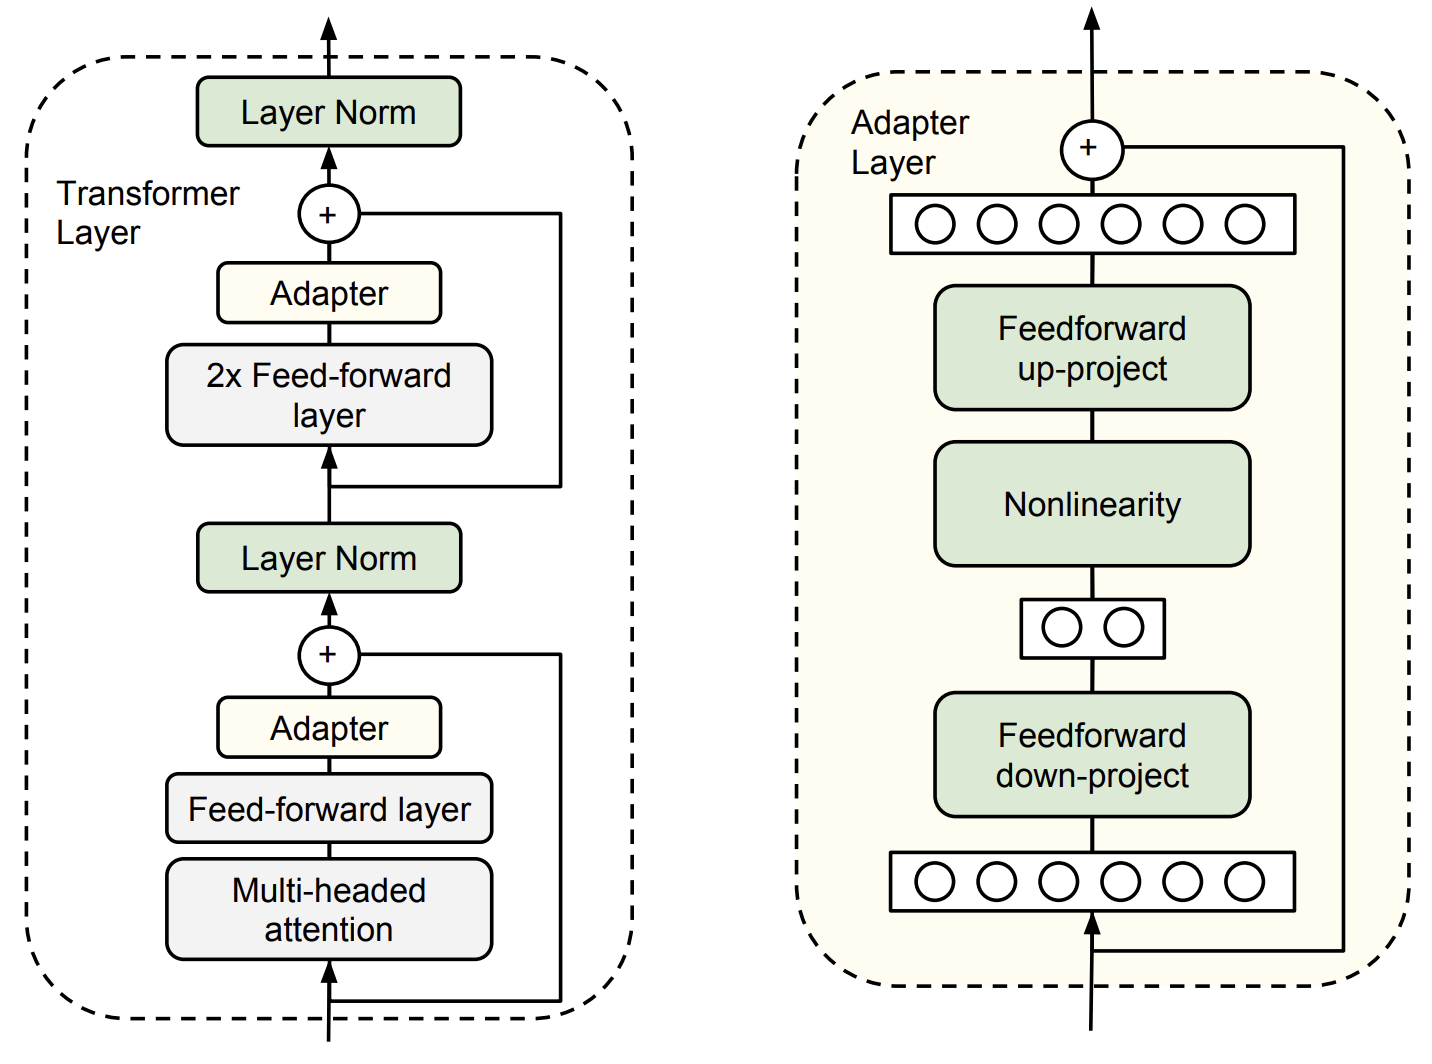

In [ ]:
class BottleneckAdapter(nn.Module):
    def __init__(self, in_dim, activation='ReLU', reduction_factor=16):
        super().__init__()
        hidden_dim = in_dim // reduction_factor
        self.adapter_downsample = nn.Linear(in_dim, hidden_dim)
        self.activation = getattr(nn, activation)()
        self.adapter_upsample = nn.Linear(hidden_dim, in_dim)
        # Zero-init the up-projection so the adapter starts as identity.
        nn.init.zeros_(self.adapter_upsample.weight)
        nn.init.zeros_(self.adapter_upsample.bias)

    def forward(self, x_in):
        x = self.adapter_downsample(x_in)
        x = self.activation(x)
        x = self.adapter_upsample(x)
        return x + x_in

In [ ]:
def add_bottleneck_adapter(model):
    for block in model.blocks:
        block.attn.proj = nn.Sequential(block.attn.proj,
                                        BottleneckAdapter(block.attn.proj.out_features))
        block.mlp = nn.Sequential(block.mlp,
                                  BottleneckAdapter(block.mlp.fc2.out_features))

In [ ]:
def freeze_model_bottleneck(model):
    for name, param in model.named_parameters():
        # Keep adapters + layer norms trainable.
        if not ('adapter' in name or 'norm1' in name or 'norm2' in name):
            param.requires_grad = False

### 4.2. AdaptFormer

[AdaptFormer](https://arxiv.org/abs/2205.13535) is similar, but inserted once per block
and placed in parallel with the pretrained MLP branch. Here the layer norms stay frozen.


![AdaptFormer](https://d3i71xaburhd42.cloudfront.net/2fe2f849b94cf08b559226bc9d78adcaef5ef186/4-Figure2-1.png)

In [14]:
class AdaptFormer(nn.Module):
    def __init__(self, layer_norm, linear, activation='ReLU', reduction_factor=8):
        super().__init__()
        self.layer_norm = layer_norm
        self.linear = linear
        self.adapter_alpha = nn.Parameter(torch.ones(1))

        in_dim = self.linear.fc2.out_features
        hidden_dim = in_dim // reduction_factor
        self.adapter_downsample = nn.Linear(in_dim, hidden_dim)
        self.activation = getattr(nn, activation)()
        self.adapter_upsample = nn.Linear(hidden_dim, in_dim)
        nn.init.zeros_(self.adapter_upsample.weight)
        nn.init.zeros_(self.adapter_upsample.bias)

    def forward(self, x):
        main_x = self.linear(self.layer_norm(x))
        adapted_x = self.adapter_upsample(self.activation(self.adapter_downsample(x)))
        return main_x + self.adapter_alpha * adapted_x

In [15]:
def add_adaptformer(model):
    for block in model.blocks:
        # Fold the (frozen) norm2 into the adapter wrapper, replace it by identity.
        block.mlp = AdaptFormer(block.norm2, block.mlp)
        block.norm2 = nn.Identity()

In [16]:
def freeze_model_adaptformer(model):
    for name, param in model.named_parameters():
        if 'adapter' not in name:
            param.requires_grad = False

### 4.3. LoRA

[LoRA (low-rank adaptation)](https://arxiv.org/abs/2106.09685) acts on the query and value
branches of attention, in parallel with the main projection, with no activation and with
learnable low-rank matrices (no bias). The scaling $\alpha$ is fixed.

$$x_{\text{out}} = \text{Linear}(x) + \alpha\,(x\,W_d\,W_u),\quad
  W_d\in\mathbb R^{d\times r},\; W_u\in\mathbb R^{r\times d}$$

In a ViT the `qkv` projection is fused, so we add LoRA to the Q and V slices and leave K
unchanged (concatenated with zeros).

![LoRA](https://miro.medium.com/v2/resize:fit:299/1*BCs63SXaAu3NKqUaTLTH2g.png)


In [17]:
class LoRA(nn.Module):
    def __init__(self, linear_layer, in_dim, rank=32, alpha=16):
        super().__init__()
        self.linear_layer = linear_layer
        std = 1.0 / torch.sqrt(torch.tensor(rank).float())
        # W_d is random, W_u is zero, so the product starts at zero.
        self.adapter_Q_downsample = nn.Parameter(torch.randn(in_dim, rank) * std)
        self.adapter_Q_upsample = nn.Parameter(torch.zeros(rank, in_dim))
        self.adapter_V_downsample = nn.Parameter(torch.randn(in_dim, rank) * std)
        self.adapter_V_upsample = nn.Parameter(torch.zeros(rank, in_dim))
        self.adapter_alpha = alpha

    def forward(self, x):
        x_q = self.adapter_alpha * (x @ self.adapter_Q_downsample @ self.adapter_Q_upsample)
        x_v = self.adapter_alpha * (x @ self.adapter_V_downsample @ self.adapter_V_upsample)
        x_lora = torch.cat([x_q, torch.zeros_like(x_v), x_v], dim=-1)  # [Q | K | V]
        return self.linear_layer(x) + x_lora

In [18]:
def add_lora(model, rank=32, alpha=16):
    for block in model.blocks:
        block.attn.qkv = LoRA(block.attn.qkv, block.attn.qkv.in_features,
                              rank=rank, alpha=alpha)

In [19]:
def freeze_model_lora(model):
    for name, param in model.named_parameters():
        if 'adapter' not in name:
            param.requires_grad = False

### 4.4. VeRA

[VeRA (vector-based random matrix adaptation)](https://arxiv.org/abs/2310.11454) is close
to LoRA, except the low-rank matrices $A, B$ are random, frozen, and shared across layers.
Only the scaling vectors $d$ (length $r$) and $b$ (length $d$) are trained:

$$\Delta x = \alpha\,\big((x\,A)\odot d\big)\,B \odot b.$$

This makes VeRA much more parameter-efficient than LoRA.

<img src="https://storage.googleapis.com/zenn-user-upload/19a06e60f7b1-20231022.png" width="400"/>


In [20]:
class VeRA(nn.Module):
    def __init__(self, linear_layer, in_dim,
                 q_downsample, v_downsample, q_upsample, v_upsample,
                 rank=32, alpha=16):
        super().__init__()
        self.linear_layer = linear_layer
        # Shared, frozen random projections (registered as buffers, not parameters).
        self.register_buffer('q_downsample', q_downsample)
        self.register_buffer('v_downsample', v_downsample)
        self.register_buffer('q_upsample', q_upsample)
        self.register_buffer('v_upsample', v_upsample)
        self.alpha = alpha

        # Trainable scaling vectors. d ~ small positive, b starts at 0.
        self.adapter_qd = nn.Parameter(torch.empty(rank).uniform_(1e-5, 1.0))
        self.adapter_vd = nn.Parameter(torch.empty(rank).uniform_(1e-5, 1.0))
        self.adapter_qb = nn.Parameter(torch.zeros(in_dim))
        self.adapter_vb = nn.Parameter(torch.zeros(in_dim))

    def forward(self, x):
        # x: [B, L, d]. d-vectors scale the rank dim, b-vectors scale the output dim.
        x_q = self.alpha * (((x @ self.q_downsample) * self.adapter_qd)
                            @ self.q_upsample) * self.adapter_qb
        x_v = self.alpha * (((x @ self.v_downsample) * self.adapter_vd)
                            @ self.v_upsample) * self.adapter_vb
        x_lora = torch.cat([x_q, torch.zeros_like(x_v), x_v], dim=-1)
        return self.linear_layer(x) + x_lora

In [21]:
def add_vera(model, rank=32):
    in_dim = model.norm.normalized_shape[0]

    # One set of shared random matrices for the whole network.
    q_downsample = torch.empty(in_dim, rank)
    v_downsample = torch.empty(in_dim, rank)
    q_upsample = torch.empty(rank, in_dim)
    v_upsample = torch.empty(rank, in_dim)
    for t in (q_downsample, v_downsample, q_upsample, v_upsample):
        nn.init.kaiming_uniform_(t)

    for block in model.blocks:
        block.attn.qkv = VeRA(block.attn.qkv, block.attn.qkv.in_features,
                              q_downsample, v_downsample, q_upsample, v_upsample,
                              rank=rank)

In [22]:
def freeze_model_vera(model):
    for name, param in model.named_parameters():
        if 'adapter' not in name:
            param.requires_grad = False

### 4.5. Visual prompt tuning

This one is not really an adapter. [Visual prompt tuning](https://arxiv.org/pdf/2203.12119.pdf)
freezes every backbone parameter and only learns a set of prompt tokens prepended to the
input sequence, either at the first layer only or at every layer except the last.

<img src="https://img-blog.csdnimg.cn/fe4b4591fd624532a6de5d898b5c1ead.png" width="800"/>


In [ ]:
class PromptTuning(nn.Module):
    def __init__(self, num_tokens, token_dim=384):
        super().__init__()
        self.num_tokens = num_tokens
        self.adapter_prompts = nn.Parameter(torch.randn(num_tokens, token_dim) * 0.02)

    def forward(self, x):
        prompts = self.adapter_prompts.unsqueeze(0).expand(x.shape[0], -1, -1)
        return torch.cat([prompts, x], dim=1)

In [ ]:
def add_prompttuning(model, all_layers=True, num_tokens=128):
    token_dim = model.norm.normalized_shape[0]
    num_layers = len(model.blocks) - 1 if all_layers else 1
    for block_id in range(num_layers):
        model.blocks[block_id] = nn.Sequential(
            PromptTuning(num_tokens, token_dim), model.blocks[block_id])

In [ ]:
def freeze_model_prompttuning(model):
    for name, param in model.named_parameters():
        if 'adapter' not in name:
            param.requires_grad = False

## 4b. Baseline: off-the-shelf DINOv2 on PCam (no adaptation)

DINOv2 was pretrained on natural images, not histopathology. Before adding any adapter,
let's check how well the frozen pretrained backbone already transfers to PCam.

We freeze every backbone parameter and train only a linear-probing head on the CLS
features. This is the standard linear-probe evaluation of a foundation model, and it is our
lower bound: any adapter that is worth its parameters should beat it. Training a linear head
on frozen features is the fairest way to read off how good the off-the-shelf representation
is without touching the backbone.


In [39]:
BATCH_SIZE = 16
NUM_EPOCHS = 3
OPTIMIZER_TYPE = 'Adam'
BASE_LR = 3e-4
CRITERION_TYPE = 'BCELoss'

In [40]:
def build_frozen_baseline():
    """Frozen DINOv2 backbone + trainable linear-probing head (no adapter)."""
    model = build_dino('vits')
    for p in model.parameters():        # freeze the whole backbone
        p.requires_grad = False
    add_linear_probing(model, feature_dim=DINO_FEATURE_DIM['vits'])  # the head stays trainable
    return model

set_seed(0)
baseline_model = build_frozen_baseline()
report_parameters(baseline_model, 'frozen DINOv2 + linear probe')

Using cache found in /linkhome/rech/genysv01/ucy78gw/.cache/torch/hub/facebookresearch_dinov2_main


frozen DINOv2 + linear probe: 385 trainable / 22,056,961 total (0.00%)


(385, 22056961)

In [41]:
# Train ONLY the linear head on top of the frozen, natural-image features.
set_seed(0)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, baseline_model.parameters()), lr=BASE_LR)
criterion = nn.BCELoss()

baseline_history = train_model(baseline_model, train_loader, val_loader,
                               optimizer, criterion, device, num_epochs=NUM_EPOCHS)

best_auc = max(baseline_history['val_AUC'])
best_f1 = max(baseline_history['val_F1'])
print(f'\nFrozen-backbone baseline — best val AUC {best_auc:.4f} | best val F1 {best_f1:.4f}')

train 1/3:   0%|          | 0/1434 [00:00<?, ?it/s]

val 1/3:   0%|          | 0/615 [00:00<?, ?it/s]

[ 1/3] train loss 0.4011 F1 0.8184 AUC 0.8999 | val loss 0.3557 F1 0.8519 AUC 0.9254


train 2/3:   0%|          | 0/1434 [00:00<?, ?it/s]

val 2/3:   0%|          | 0/615 [00:00<?, ?it/s]

[ 2/3] train loss 0.3323 F1 0.8591 AUC 0.9319 | val loss 0.3280 F1 0.8602 AUC 0.9333


train 3/3:   0%|          | 0/1434 [00:00<?, ?it/s]

val 3/3:   0%|          | 0/615 [00:00<?, ?it/s]

[ 3/3] train loss 0.3173 F1 0.8638 AUC 0.9379 | val loss 0.3211 F1 0.8664 AUC 0.9370

Frozen-backbone baseline — best val AUC 0.9370 | best val F1 0.8664


In [ ]:
def plot_results(results):
    """Plot validation AUC/F1 curves for every trained adapter."""
    if not results:
        print('No results to plot yet — run the training cell above.')
        return
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    for adapter, h in results.items():
        epochs = range(1, len(h['val_AUC']) + 1)
        axs[0].plot(epochs, h['val_AUC'], marker='o', label=adapter)
        axs[1].plot(epochs, h['val_F1'], marker='o', label=adapter)
    axs[0].set_title('Validation AUC'); axs[1].set_title('Validation F1')
    for ax in axs:
        ax.set_xlabel('epoch'); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()


In [ ]:
# Keep the baseline alongside the adapters so it shows up in the final comparison.
results = {'frozen (no adapter)': baseline_history}
param_stats = {'frozen (no adapter)': count_parameters(baseline_model)}

plot_results(results)

NameError: name 'baseline_history' is not defined

## 5. Training and comparison

We wrap insertion and freezing in dispatch functions, then train each adapter and collect
the results for a final comparison.


In [ ]:
ADAPTER_TYPES = ['bottleneck', 'adaptformer', 'lora', 'vera', 'prompttuning']

ADD_FN = {
    'bottleneck':   add_bottleneck_adapter,
    'adaptformer':  add_adaptformer,
    'lora':         add_lora,
    'vera':         add_vera,
    'prompttuning': add_prompttuning,
}
FREEZE_FN = {
    'bottleneck':   freeze_model_bottleneck,
    'adaptformer':  freeze_model_adaptformer,
    'lora':         freeze_model_lora,
    'vera':         freeze_model_vera,
    'prompttuning': freeze_model_prompttuning,
}

def add_adapter(model, adapter_type):
    assert adapter_type in ADAPTER_TYPES
    ADD_FN[adapter_type](model)

def freeze_model(model, adapter_type):
    assert adapter_type in ADAPTER_TYPES
    FREEZE_FN[adapter_type](model)

In [ ]:
BATCH_SIZE = 16
NUM_EPOCHS = 3
OPTIMIZER_TYPE = 'Adam'
BASE_LR = 3e-4
CRITERION_TYPE = 'BCELoss'

# Choose which adapters to run. Use the full list for the final comparison.
RUN_ADAPTERS = ['vera']  # e.g. ADAPTER_TYPES

In [ ]:
# Keep any baseline already in `results` (see Section 4b); just add the adapters.
results = dict(results) if 'results' in globals() else {}
param_stats = dict(param_stats) if 'param_stats' in globals() else {}

for adapter in RUN_ADAPTERS:
    print(f'\n=== Training adapter: {adapter} ===')
    set_seed(0)

    lr = BASE_LR / 10 if adapter == 'lora' else BASE_LR

    model = build_dino('vits')
    add_adapter(model, adapter)
    freeze_model(model, adapter)
    param_stats[adapter] = report_parameters(model, adapter)

    add_linear_probing(model, feature_dim=DINO_FEATURE_DIM['vits'])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    optimizer = getattr(torch.optim, OPTIMIZER_TYPE)(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = getattr(nn, CRITERION_TYPE)()

    results[adapter] = train_model(model, train_loader, val_loader,
                                   optimizer, criterion, device, num_epochs=NUM_EPOCHS)


=== Training adapter: lora ===


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


lora: 589,824 trainable / 22,646,400 total (2.60%)


train 1/3:   0%|          | 0/1434 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Summary table: best val AUC/F1 vs. parameter cost.
if results:
    print(f'{"adapter":<14}{"best AUC":>10}{"best F1":>10}{"trainable":>14}{"% params":>10}')
    print('-' * 58)
    for a in results:
        best_auc = max(results[a]['val_AUC'])
        best_f1 = max(results[a]['val_F1'])
        tr, tot = param_stats[a]
        print(f'{a:<14}{best_auc:>10.4f}{best_f1:>10.4f}{tr:>14,}{100*tr/tot:>9.2f}%')

adapter         best AUC   best F1     trainable  % params
----------------------------------------------------------
frozen (no adapter)    0.9370    0.8664           385     0.00%
lora              0.9807    0.9318       589,824     2.60%


---

## 6. Part 2 — Doing it with Hugging Face PEFT

Implementing every adapter by hand is useful for understanding the mechanics, but in
practice you would reach for [`peft`](https://github.com/huggingface/peft), which ships
ready-to-use implementations of LoRA, VeRA, AdaLoRA, IA3, prompt tuning and more. It works
on any `nn.Module`, not just Hugging Face models, by targeting layers by name.

Below we redo the LoRA experiment from Part 1 with PEFT, then show how little has to change
to switch to VeRA and IA3.


### 6.1. Inspecting the target layers

PEFT injects adapters into named `nn.Linear` modules. For a DINOv2 ViT the usual targets
are the attention `qkv` and `proj` layers and the MLP `fc1`/`fc2`. Let's list the module
names so we know what to target.


In [23]:
from peft import LoraConfig, VeraConfig, IA3Config, get_peft_model

# Build a fresh backbone and peek at some linear layer names.
peft_backbone = build_dino('vits')
linear_names = [n for n, m in peft_backbone.named_modules() if isinstance(m, nn.Linear)]
print('Example Linear modules:')
for n in linear_names[:8]:
    print(' ', n)
print('...')
print('total linear layers:', len(linear_names))

Using cache found in /linkhome/rech/genysv01/ucy78gw/.cache/torch/hub/facebookresearch_dinov2_main


Example Linear modules:
  blocks.0.attn.qkv
  blocks.0.attn.proj
  blocks.0.mlp.fc1
  blocks.0.mlp.fc2
  blocks.1.attn.qkv
  blocks.1.attn.proj
  blocks.1.mlp.fc1
  blocks.1.mlp.fc2
...
total linear layers: 48


### 6.2. A DINOv2 + head wrapper

PEFT wraps a single `nn.Module`, so we bundle the backbone and the linear-probing head into
one module. That way the classifier is trained alongside the LoRA parameters. We tell PEFT
to keep the head trainable via `modules_to_save`.


In [24]:
class DinoClassifier(nn.Module):
    """DINOv2 backbone (PEFT will adapt it) + a binary linear-probing head."""
    def __init__(self, backbone, feature_dim=384):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.Linear(feature_dim, 1), nn.Sigmoid())

    def forward(self, x):
        feats = self.backbone(x)          # CLS features [B, feature_dim]
        return self.head(feats)

### 6.3. LoRA with PEFT

A `LoraConfig` sets the rank `r`, the scaling `lora_alpha`, and which modules to target.
`target_modules=["qkv"]` matches every attention `qkv` projection by name, which is the same
place we patched by hand in Part 1. `get_peft_model` freezes everything else for us.


In [25]:
def build_peft_lora_model(r=32, alpha=16, target_modules=("qkv",)):
    set_seed(0)
    backbone = build_dino('vits')
    config = LoraConfig(
        r=r,
        lora_alpha=alpha,
        target_modules=list(target_modules),
        lora_dropout=0.0,
        bias='none',
    )
    backbone = get_peft_model(backbone, config)
    model = DinoClassifier(backbone, feature_dim=DINO_FEATURE_DIM['vits'])
    return model

peft_lora = build_peft_lora_model()
# PEFT's own report (backbone only):
peft_lora.backbone.print_trainable_parameters()
# Full model including the head:
report_parameters(peft_lora, 'PEFT-LoRA (with head)')

Using cache found in /linkhome/rech/genysv01/ucy78gw/.cache/torch/hub/facebookresearch_dinov2_main


trainable params: 589,824 || all params: 22,646,400 || trainable%: 2.6045
PEFT-LoRA (with head): 590,209 trainable / 22,646,785 total (2.61%)


(590209, 22646785)

Now train it with the same `train_model` loop we used in Part 1.


In [ ]:
set_seed(0)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, peft_lora.parameters()), lr=3e-4)
criterion = nn.BCELoss()

peft_history = train_model(peft_lora, train_loader, val_loader,
                           optimizer, criterion, device, num_epochs=NUM_EPOCHS)

train 1/3:   0%|          | 0/1434 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Compare our hand-written LoRA (if available) with the PEFT version.
compare = {}
if 'lora' in results:
    compare['lora (scratch)'] = results['lora']
compare['lora (peft)'] = peft_history
plot_results(compare)

NameError: name 'peft_history' is not defined

### 6.4. Swapping the method: VeRA and IA3

With PEFT, switching method means switching the config object; the training code does not
change.

- VeRA shares frozen random matrices across layers and trains small scaling vectors.
- IA3 trains even fewer parameters: per-feature rescaling vectors on selected projections.


In [ ]:
def build_peft_model(method='vera'):
    set_seed(0)
    backbone = build_dino('vits')
    if method == 'vera':
        config = VeraConfig(r=32, target_modules=['qkv'], vera_dropout=0.0)
    elif method == 'ia3':
        # IA3 needs to know which targets are "feedforward" (scaled on the output).
        config = IA3Config(target_modules=['qkv', 'fc2'],
                           feedforward_modules=['fc2'])
    else:
        raise ValueError(method)
    backbone = get_peft_model(backbone, config)
    return DinoClassifier(backbone, feature_dim=DINO_FEATURE_DIM['vits'])

for method in ['vera', 'ia3']:
    m = build_peft_model(method)
    report_parameters(m, f'PEFT-{method.upper()}')

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


PEFT-VERA: 14,593 trainable / 22,071,169 total (0.07%)


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


PEFT-IA3: 32,641 trainable / 22,089,217 total (0.15%)


In [ ]:
# Train one of them end-to-end (VeRA shown here).
peft_vera = build_peft_model('vera')
set_seed(0)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, peft_vera.parameters()), lr=3e-4)
criterion = nn.BCELoss()

peft_vera_history = train_model(peft_vera, train_loader, val_loader,
                                optimizer, criterion, device, num_epochs=NUM_EPOCHS)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


train 1/3:   0%|          | 0/1434 [00:00<?, ?it/s]

val 1/3:   0%|          | 0/615 [00:00<?, ?it/s]

[ 1/3] train loss 0.3532 F1 0.8419 AUC 0.9220 | val loss 0.2942 F1 0.8822 AUC 0.9505


train 2/3:   0%|          | 0/1434 [00:00<?, ?it/s]

val 2/3:   0%|          | 0/615 [00:00<?, ?it/s]

[ 2/3] train loss 0.2400 F1 0.9003 AUC 0.9649 | val loss 0.2257 F1 0.9081 AUC 0.9689


train 3/3:   0%|          | 0/1434 [00:00<?, ?it/s]

val 3/3:   0%|          | 0/615 [00:00<?, ?it/s]

[ 3/3] train loss 0.1886 F1 0.9248 AUC 0.9781 | val loss 0.1934 F1 0.9245 AUC 0.9773


### 6.5. Saving and loading adapters

One practical advantage: PEFT saves only the adapter weights (a few hundred KB), not the
full backbone. So you can ship many task-specific adapters for a single shared model.


In [ ]:
# Save just the adapter (backbone weights are NOT duplicated).
peft_lora.backbone.save_pretrained('dino_lora_pcam')
print('Saved files:', os.listdir('dino_lora_pcam'))

# To reload later:
#   from peft import PeftModel
#   backbone = build_dino('vits')
#   backbone = PeftModel.from_pretrained(backbone, 'dino_lora_pcam')

Saved files: ['README.md', 'adapter_config.json', 'adapter_model.safetensors']


### 6.6. Takeaways

- Same idea, less code. `LoraConfig` + `get_peft_model` reproduces our manual LoRA in a few
  lines and freezes the backbone for us.
- Method equals config. Switching to VeRA or IA3 only changes the config object.
- Targeting by name. `target_modules` selects the `nn.Linear` layers to adapt, the same
  layers we patched by hand.
- Small checkpoints. Adapters are serialized on their own, separately from the backbone, so
  one foundation model can serve many tasks.

As a follow-up you could loop over several PEFT methods, as we did in Part 1, and plot all
the validation curves together to compare accuracy against parameter cost.
